In [1]:
using Pkg

# using Pkg
# Pkg.activate(@__DIR__)
# Pkg.develop(url = "https://github.com/IncartStudents/IBoxAccess.jl")
# Pkg.develop(url = "https://github.com/IncartStudents/Descriptors.jl")
# Pkg.develop(url = "https://github.com/a-mikhaylov/FileUnv_jll.jl.git")
# Pkg.develop(url = "https://github.com/sairus7/wfdb_wrapper_jll.jl.git")
# Pkg.develop(url = "https://github.com/IncartStudents/FileUtils.jl")
# Pkg.develop(url = "https://github.com/IncartStudents/TimeSamplings.jl")
# Pkg.develop(path=joinpath(@__DIR__, ".."))
# using ArrhythmRelations
# Pkg.add("Plots")
# using Plots

In [2]:
Pkg.activate(pwd())

  Activating project at `c:\Users\fifteen\.julia\dev\ArrhythmRelations`


In [3]:
Pkg.instantiate()

Precompiling packages...
   2239.7 ms  ✓ mtdev_jll
   2457.4 ms  ✓ Xorg_libICE_jll
   2264.4 ms  ✓ LLVMOpenMP_jll
   2093.6 ms  ✓ wfdb_wrapper_jll
   2256.5 ms  ✓ libaec_jll
   1552.5 ms  ✓ EpollShim_jll
   1540.2 ms  ✓ Xorg_libXdmcp_jll
   1560.9 ms  ✓ Xorg_libXau_jll
   1761.7 ms  ✓ FileUnv_jll
   1342.7 ms  ✓ Xorg_xtrans_jll
   1335.6 ms  ✓ eudev_jll
   1324.5 ms  ✓ Libmount_jll
   2046.4 ms  ✓ MicrosoftMPI_jll
   3786.2 ms  ✓ Ghostscript_jll
   1729.3 ms  ✓ libevdev_jll
   1663.6 ms  ✓ Dbus_jll
   2577.0 ms  ✓ EzXML
   1442.7 ms  ✓ IntervalSets → IntervalSetsRecipesBaseExt
   1220.8 ms  ✓ InlineStrings → ParsersExt
   3341.4 ms  ✓ MPICH_jll
   1336.1 ms  ✓ ColorVectorSpace → SpecialFunctionsExt
   2987.9 ms  ✓ IntelOpenMP_jll
   1976.1 ms  ✓ Conda
   3144.8 ms  ✓ oneTBB_jll
   1385.0 ms  ✓ Wayland_jll
   1485.3 ms  ✓ Xorg_xcb_util_jll
   1456.4 ms  ✓ Xorg_libX11_jll
   1161.0 ms  ✓ XMLDict
   4787.7 ms  ✓ HypothesisTests
   2092.5 ms  ✓ WeakRefStrings
   1763.4 ms  ✓ Xorg_libXfixes

In [4]:
using ArrhythmRelations

In [5]:
path = "C:\\Users\\fifteen\\.julia\\dev\\ArrhythmRelations\\test\\xmltest\\"
folders = ["ChildArithm.avt", "Ishem_Arithm.avt", "ReoBreath.avt", "Seminar_AD_FP.avt", "VMT_Arrh_101159.avt"]

5-element Vector{String}:
 "ChildArithm.avt"
 "Ishem_Arithm.avt"
 "ReoBreath.avt"
 "Seminar_AD_FP.avt"
 "VMT_Arrh_101159.avt"

In [6]:
ArrHR(Markup(path * folders[1]))

p_values = [NaN, NaN, NaN, NaN, NaN, NaN]
p_values_V = [1.0, 0.0, 1.0, 1.0, 0.0, NaN]
p_values_S = [1.0, NaN, NaN, NaN, NaN, NaN]


In [7]:
data = []
for el in folders
    push!(data, ArrHR(Markup(path * el)))
end

In [ ]:
p(x) = 1/sqrt(2pi) * exp(-x^2/2)

In [ ]:
histogram(data[3].empty[3], normalized=:probability, label="without arrs")
plot!(p, lw=3, label="normal distribution")

In [ ]:
histogram(data[3].arrs[3], normalized=:probability, label="before arrs")
plot!(p, lw=3, label="normal distribution")

In [8]:
mkps = []
for el in folders
    mkp = Markup(path * el)
    push!(mkps, mkp)
end

In [15]:
const windows = [6, 12, 18, 30, 60, 90]
function get_hr(mkp::Markup, i::Int, lag::Int)
    hr = mkp.trends.hr10
    hr_without = copy(hr)
    hr_before = zeros(length(hr))
    structure = ArrHR(mkp)
    
    prev = 0
    for el in structure.arr_windows[i]
        hr_without[el:(el + 3 * windows[i])] .= 0
        hr_before[el:(el + windows[i])] .= hr[el:(el + windows[i])]
        prev = el
    end
    
    # check = []
    # for (i, el) in enumerate(hr_before)
    #     if el >= 0
    #         push!(check, i)
    #     end
    # end
    # println(check)

    hr_without_lag = copy(hr_without)
    hr_before_lag = copy(hr_before)
    
    for i in 1:lag
        popfirst!(hr_without_lag)
        push!(hr_without_lag, 0)
        popfirst!(hr_before_lag)
        push!(hr_before_lag, 0)
    end

    bad_index_without = []
    bad_index_before = []
    for i in eachindex(hr)
        if (hr_without[i] <= 0) || (hr_without_lag[i] <= 0)
            push!(bad_index_without, i)
        end
        if (hr_before[i] <= 0) || (hr_before_lag[i] <= 0)
            push!(bad_index_before, i)
        end
    end
    
    # println(bad_index_before)

    deleteat!(hr_without, bad_index_without)
    deleteat!(hr_without_lag, bad_index_without)
    deleteat!(hr_before, bad_index_before)
    deleteat!(hr_before_lag, bad_index_before)

    return hr_without, hr_without_lag, hr_before, hr_before_lag
end

get_hr (generic function with 1 method)

In [ ]:
x1, y1, x2, y2 = get_hr(mkps[2], 1, 1)

In [ ]:
scatter(y1, x1, aspect_ratio = 1, size = (400, 400), label="without arrs")
scatter!(y2, x2, label="before arrs")

In [9]:
Pkg.add("StatsBase")
using StatsBase

   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\fifteen\.julia\dev\ArrhythmRelations\Project.toml`
    Manifest No packages added to or removed from `C:\Users\fifteen\.julia\dev\ArrhythmRelations\Manifest.toml`


In [33]:
function get_corkendall(mkp::Markup)
    hr = mkp.trends.hr10
    data = ArrHR(mkp)
    arr_kendall = []
    before_arr = []
    for el in data.arr_windows[2]
        push!(before_arr, hr[el:(el + windows[2] - 1)])
        push!(arr_kendall, corkendall(hr[el:(el + windows[2] - 1)], Vector(1:windows[1])))
    end
    empty_kendall = []
    for el in data.empty_windows[2]
        push!(empty_kendall, corkendall(hr[el:(el + windows[2] - 1)], Vector(1:windows[1])))
    end

    if length(arr_kendall) < length(empty_kendall)
        empty_kendall = sample(empty_kendall, length(arr_kendall), replace=false)
    end

    return before_arr
    # return arr_kendall, empty_kendall
end

get_corkendall (generic function with 1 method)

In [11]:
Pkg.add("Plots")

   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\fifteen\.julia\dev\ArrhythmRelations\Project.toml`
    Manifest No packages added to or removed from `C:\Users\fifteen\.julia\dev\ArrhythmRelations\Manifest.toml`


In [12]:
using Plots

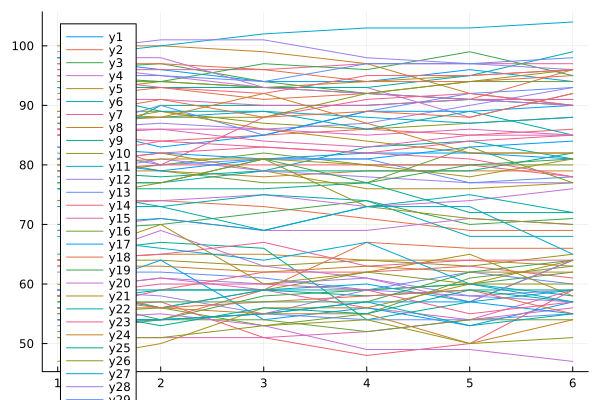

In [32]:
p = plot()               # создаём пустой график
for y in arr
    plot!(y)   # добавляем каждую кривую
end
p

In [49]:
Pkg.add("DataFrames")

   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\fifteen\.julia\dev\ArrhythmRelations\Project.toml`
    Manifest No packages added to or removed from `C:\Users\fifteen\.julia\dev\ArrhythmRelations\Manifest.toml`


In [50]:
using DataFrames

In [44]:
using TimeSamplings

In [51]:
function arrhr2csv(mkp::Markup)
    hr = mkp.trends.hr10

    sampler = EventSampler(mkp.qrs.timeQ ./ (mkp.exam.fs_base * 10))
    qrs_to_10(arr_qrs::BitVector, len::Int, sampler::EventSampler) = [any(arr_qrs[sampler((i - 1):i)]) for i in 1:len]
    arr = qrs_to_10(mkp.arrs[1].BitSet, length(hr), sampler)
    
    fn = basename(mkp.path)

    df = DataFrame(hr = hr, arr = arr)
    # data = hcat(hr, arr)
    fp = "C:\\Users\\fifteen\\.julia\\dev\\ArrhythmRelations\\test\\csv\\" * fn

    CSV.write(fp * ".csv", df)
end

arrhr2csv (generic function with 1 method)

In [52]:
arrhr2csv.(mkps)

5-element Vector{String}:
 "C:\\Users\\fifteen\\.julia\\dev\\ArrhythmRelations\\test\\csv\\ChildArithm.avt.csv"
 "C:\\Users\\fifteen\\.julia\\dev\\ArrhythmRelations\\test\\csv\\Ishem_Arithm.avt.csv"
 "C:\\Users\\fifteen\\.julia\\dev\\ArrhythmRelations\\test\\csv\\ReoBreath.avt.csv"
 "C:\\Users\\fifteen\\.julia\\dev\\ArrhythmRelations\\test\\csv\\Seminar_AD_FP.avt.csv"
 "C:\\Users\\fifteen\\.julia\\dev\\ArrhythmRelations\\test\\csv\\VMT_Arrh_101159.avt.csv"

In [34]:
arr = get_corkendall(mkps[2])

ErrorException: Vectors must have same length

In [ ]:
arr_kendall, empty_kendall = get_corkendall(mkps[2])

In [ ]:
histogram(arr_kendall, normalized=:probability, bins=10, label="arrs")
histogram!(empty_kendall, normalized=:probability, bins=10, label="without arrs")

In [ ]:
histogram(empty_kendall, normalized=:probability, bins=10, label="without arrs")
histogram!(arr_kendall, normalized=:probability, bins=10, label="arrs")

In [ ]:
length(arr_kendall)